In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json

In [5]:
line = xt.load('../Studies/MomentumAcceptance/ErrorVariants/sps_inj_q20_aper_momentum_scan.json')
env = line.env

#Context and parameters
context = xo.ContextCpu()

xi = 0.5 #normalised chroma -- same for qx and qy
qx = 20.13
qy = 20.18

num_particles  = 2000
num_turns = 6000

sweep = 6000
plane = 'DPneg'
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

#Optimisation if needed
env.vars['qph_setvalue'] = xi
env.vars['qpv_setvalue'] = xi
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi*qx, dqy=xi*qy, tol=1e-2, tag='chrom'),
    ])

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.09269                           
Matching: model call n. 7 penalty = 6.4486e-06              
Optimize - end penalty:  6.4486e-06                            


# Test footprint

In [6]:
coeffs = line.get_amplitude_detuning_coefficients(nemitt_x=2e-6, nemitt_y=2e-6, num_turns=1000, a0_sigmas=0.01, a1_sigmas=0.1, a2_sigmas=0.2)

In [7]:
fp = line.get_footprint(
    nemitt_x=2e-6, nemitt_y=2e-6,
    #mode='uniform_action_grid'  # or default polar grid
)

Tracking particles for footprint...
Done tracking.
Done computing footprint.


In [15]:
fp.qx

array([[0.12999725, 0.13000107, 0.13000488, 0.13001251, 0.13002396,
        0.13003922, 0.13005829, 0.13008118, 0.13010788, 0.13013458],
       [0.12999725, 0.12999725, 0.13000107, 0.1300087 , 0.13001251,
        0.13002396, 0.1300354 , 0.13004684, 0.1300621 , 0.13007736],
       [0.12999725, 0.12999725, 0.12999344, 0.12999344, 0.12998962,
        0.12998581, 0.12997818, 0.12997055, 0.12996292, 0.12995529],
       [0.12999725, 0.12999344, 0.12998581, 0.12997055, 0.12995529,
        0.12992859, 0.12990189, 0.12986755, 0.12982559, 0.12978363],
       [0.12999725, 0.12998962, 0.12997437, 0.12994766, 0.12991333,
        0.12986374, 0.12981033, 0.12974167, 0.12966537, 0.12958145],
       [0.12999725, 0.12998581, 0.12996292, 0.12992096, 0.12986755,
        0.12979889, 0.12971497, 0.12961197, 0.12949753, 0.12936783],
       [0.12999725, 0.12998581, 0.12995148, 0.12989807, 0.12982559,
        0.12973404, 0.12962341, 0.12949371, 0.12934113, 0.12916565],
       [0.12999725, 0.12998199, 0.1299438

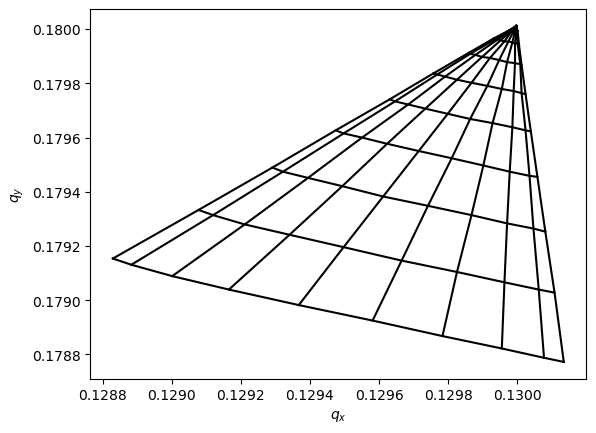

In [10]:
fp.plot()

In [11]:
tw = line.twiss()
tw.qx, tw.qy

(np.float64(20.129999998778526), np.float64(20.17999999998025))

In [12]:
coeffs

{'det_xx': np.float64(108.00579049024886),
 'det_yy': np.float64(-642.8518256419774),
 'det_xy': np.float64(-917.6033115356544),
 'det_yx': np.float64(-917.9553787064493)}

# Test NL chromaticity

In [21]:
def generate_delta_sampling(delta_min, delta_max, step=None, num_points=None):
    if step is None and num_points is None:
        raise ValueError("Either 'step' or 'num_points' must be provided.")
    if step is None:
        step = (delta_max - delta_min) / num_points

    i_min = int(np.ceil(delta_min / step))
    i_max = int(np.floor(delta_max / step))

    arr = step * np.arange(i_min, i_max + 1)
    return arr

def twiss_scan(line, delta_min, delta_max, step=None, num_points=None):
    delta_values = generate_delta_sampling(delta_min, delta_max, step, num_points)
    
    idx_zero = np.where(delta_values == 0)[0][0]
    tw0 = line.twiss4d(delta0=0.0)
    twisses = []
    # twiss_pos.append(tw0)
    # twiss_neg.append(tw0)

    for delta in delta_values[:idx_zero][::-1]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co) if len(twisses)>0 else tw0)
    twisses = twisses[::-1]
    twisses.append(tw0)
    for delta in delta_values[idx_zero + 1:]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co))
    
    return delta_values, twisses

In [22]:
delta_values, twisses = twiss_scan(line, -1e-2, 1e-2, step=1e-4)

In [23]:
twisses[0]

TwissTable: 32247 rows, 70 cols
name                             s             x            px             y            py ...
sps$start                        0    -0.0765375   -0.00140338  -0.000295118   6.12862e-06
begi.10010                       0    -0.0765375   -0.00140338  -0.000295118   6.12862e-06
qf.10010                         0    -0.0765375   -0.00140338  -0.000295118   6.12862e-06
drift_0..0                   3.085    -0.0766075    0.00135891   -0.00029225  -4.27093e-06
veqf.10010.b_aper           3.2504    -0.0763804    0.00135891  -0.000292963  -4.27093e-06
drift_0..1                  3.2504    -0.0763804    0.00135891  -0.000292963  -4.27093e-06
veba.10030.a_aper           3.2516    -0.0763788    0.00135891  -0.000292968  -4.27093e-06
drift_0..2                  3.2516    -0.0763788    0.00135891  -0.000292968  -4.27093e-06
mba.10030_entry            3.44499    -0.0761133    0.00135891  -0.000293803  -4.27093e-06
mba.10030..entry_map       3.44499    -0.0761133    0.

In [39]:
fitqx1 = np.polyfit(delta_values, [twiss.qx for twiss in twisses], deg=1)
fitqx2 = np.polyfit(delta_values, [twiss.qx for twiss in twisses], deg=2)
fitqx3 = np.polyfit(delta_values, [twiss.qx for twiss in twisses], deg=3)

fitqy2 = np.polyfit(delta_values, [twiss.qy for twiss in twisses], deg=2)

In [ ]:
fitqx2[0]

array([-58.51083324,  10.15295118,  20.13004342])

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_73940/574528492.py:11: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel('$\delta$')


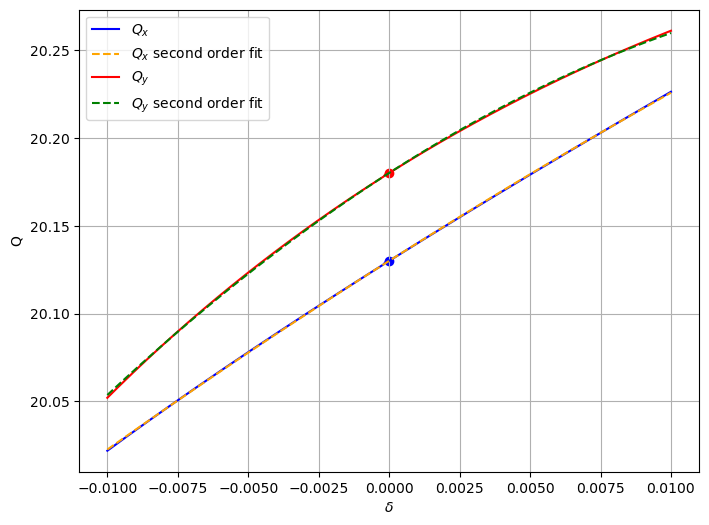

In [42]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(delta_values, [twiss.qx for twiss in twisses], color='blue', label='$Q_x$')
#ax.plot(delta_values, fitqx1[0]*delta_values + fitqx1[1], '--', color = 'lightblue')
ax.plot(delta_values, fitqx2[0]*delta_values**2 + fitqx2[1]*delta_values + fitqx2[2], '--', color = 'orange', label='$Q_x$ second order fit')
# ax.plot(delta_values, fitqx3[0]*delta_values**3 + fitqx3[1]*delta_values**2 + fitqx3[2]**delta_values + fitqx3[3], '--', color = 'green')
ax.plot(delta_values, [twiss.qy for twiss in twisses], color='red', label='$Q_y$')
ax.plot(delta_values, fitqy2[0]*delta_values**2 + fitqy2[1]*delta_values + fitqy2[2], '--',color='green', label='$Q_y$ second order fit')
ax.scatter([0.0], [20.13], color='blue')
ax.scatter([0.0], [20.18], color='red')
ax.legend()
ax.set_xlabel('$\delta$')
ax.set_ylabel('Q')
ax.grid()

There seems to be NL chromaticity: $$Q_x = Q_{x,0} + Q^{'}_x\cdot\delta + Q^{''}_x\cdot\delta^2$$

## Dispersion

In [ ]:
chromas = np.round(np.linspace(-1.5, 1.5, int(3/0.1 +1)), 1)

array([-1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7, -0.6, -0.5,
       -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,
        0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5])

In [48]:
def twiss_scan(line, delta_min, delta_max, step=None, num_points=None):
    delta_values = generate_delta_sampling(delta_min, delta_max, step, num_points)

    idx_zero = np.where(delta_values == 0)[0][0]
    tw0 = line.twiss4d(delta0=0.0)

    twisses = []

    # ---- negative deltas (going down from 0)
    for delta in delta_values[:idx_zero][::-1]:
        try:
            if len(twisses) > 0 and twisses[-1] is not None:
                tw = line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co)
            else:
                tw = line.twiss4d(delta0=delta, co_guess=tw0.particle_on_co)

            twisses.append(tw)

        except Exception as err:
            print(f"Twiss failed at delta={delta:.6e} (neg side): {err}")
            twisses.append(None)

    twisses = twisses[::-1]

    # ---- delta = 0
    twisses.append(tw0)

    # ---- positive deltas
    for delta in delta_values[idx_zero + 1:]:
        try:
            if twisses[-1] is not None:
                tw = line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co)
            else:
                # fallback: restart from tw0 if previous failed
                tw = line.twiss4d(delta0=delta, co_guess=tw0.particle_on_co)

            twisses.append(tw)

        except Exception as err:
            print(f"Twiss failed at delta={delta:.6e} (pos side): {err}")
            twisses.append(None)

    return delta_values, twisses


In [49]:
delta_values = {}
twisses = {}
qx = 20.13
qy = 20.18
chromas = np.round(np.linspace(-1.5, 1.5, int(3/0.1 +1)), 1)
for xi in chromas:
    print(xi)
    line = xt.load('../Studies/MomentumAcceptance/ErrorVariants/sps_inj_q20_aper_momentum_scan.json')
    env = line.env

    #Optimisation if needed
    env.vars['qph_setvalue'] = xi
    env.vars['qpv_setvalue'] = xi
    opt = line.match(
        method='6d', # <- passed to twiss
        vary=[
            xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
        ],
        targets = [
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
            xt.TargetSet(dqx=xi*qx, dqy=xi*qy, tol=1e-2, tag='chrom'),
        ])
    dd, tt = twiss_scan(line, -1e-2, 1e-2, step=1e-4)
    delta_values[xi] = dd.copy()
    twisses[xi] = tt.copy()
    print(' ')

-1.5


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.03215                           
Matching: model call n. 7 penalty = 1.3159e-05              
Optimize - end penalty:  1.31586e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Twiss failed at delta=4.100000e-03 (pos side): 
Twiss failed at delta=4.200000e-03 (pos side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([0.96891415, 1.03208318, 1.        , 1.        ])
Twiss failed at delta=4.300000e-03 (pos side): Invalid n1
Twiss failed at delta=5.800000e-03 (pos side): Invalid n2
Twiss failed at delta=5.900000e-03 (pos side): Invalid n2
Twiss failed at delta=6.000000e-03 (pos side): Invalid n2
 
-1.4


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.03062                           
Matching: model call n. 7 penalty = 1.0057e-05              
Optimize - end penalty:  1.00568e-05                            
Twiss failed at delta=4.400000e-03 (pos side): Invalid n1
Twiss failed at delta=4.500000e-03 (pos side): Invalid n1
Twiss failed at delta=4.600000e-03 (pos side): Invalid n1
Twiss failed at delta=6.200000e-03 (pos side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 1.01777572, 0.98253474, 1.        ,
       1.        ])
Twiss failed at delta=6.300000e-03 (pos side): Invalid n2
Twiss failed at delta=6.400000e-03 (pos side): Invalid n2


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Twiss failed at delta=6.500000e-03 (pos side): 
 
-1.3


...

Done loading line from dict.           
                                             
Optimize - start penalty: 0.1304                            
Matching: model call n. 7 penalty = 5.8443e-05              
Optimize - end penalty:  5.84426e-05                            
Twiss failed at delta=-4.600000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([0.79715137, 1.        , 1.        , 1.25446689, 1.        ,
       1.        ])
Twiss failed at delta=-4.700000e-03 (neg side): Invalid n2
Twiss failed at delta=-4.800000e-03 (neg side): Invalid n1
Twiss failed at delta=-4.900000e-03 (neg side): Invalid n2


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search
Twiss failed at delta=-5.000000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([0.9435829 , 0.9435829 , 1.05979029, 1.05979029])
Twiss failed at delta=-5.700000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigen

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.1351                            
Matching: model call n. 7 penalty = 2.8178e-05              
Optimize - end penalty:  2.81781e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Twiss failed at delta=-4.300000e-03 (neg side): 
Twiss failed at delta=-4.400000e-03 (neg side): Invalid n1
Twiss failed at delta=-4.500000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.0774566 , 1.0774566 , 0.92811163, 0.92811163])
Twiss failed at delta=-4.600000e-03 (neg side): Invalid n1
Twiss failed at delta=-4.700000e-03 (neg side): Invalid n1
Twiss failed at delta=-5.300000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 1.03205109, 0.96894428, 1.        ,
       1.        ])
Twis

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.1399                            
Matching: model call n. 7 penalty = 3.9944e-05              
Optimize - end penalty:  3.99438e-05                            


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.


Twiss failed at delta=-4.000000e-03 (neg side): 
Twiss failed at delta=-4.100000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([0.93820349, 0.93820349, 1.06586685, 1.06586685])
Twiss failed at delta=-4.200000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([0.96577049, 1.03544269, 1.        , 1.        ])
Twiss failed at delta=-4.300000e-03 (neg side): Invalid n1
Twiss failed at delta=-5.000000e-03 (neg side): One-turn matrix is unstable. Magnitudes of eigenvalues are:
array([1.        , 1.        , 1.02364854, 0.

In [71]:
xs_pos = {}
xs_neg = {}
dxs_pos = {}
dxs_neg = {}
ddxs_pos = {}
ddxs_neg = {}
qxs = {}
qys = {}

for xi in chromas:
    qxs[xi] = []
    qys[xi] = []
    dxs_pos[xi] = []
    dxs_neg[xi] = []
    ddxs_pos[xi] = []
    ddxs_neg[xi] = []
    xs_pos[xi] = []
    xs_neg[xi] = []
    for twiss in twisses[xi]:
        if twiss is not None:
            qxs[xi].append(twiss.qx)
            qys[xi].append(twiss.qy)
            dxs_pos[xi].append(twiss.rows['qd.61110'].dx[0])
            dxs_neg[xi].append(twiss.rows['qd.52510'].dx[0])
            ddxs_pos[xi].append(twiss.rows['qd.61110'].ddx[0])
            ddxs_neg[xi].append(twiss.rows['qd.52510'].ddx[0])
            xs_pos[xi].append(twiss.rows['qd.61110'].x[0])
            xs_neg[xi].append(twiss.rows['qd.52510'].x[0])
    else:
        qxs[xi].append(None)
        qys[xi].append(None)
        dxs_pos[xi].append(None)
        dxs_neg[xi].append(None)
        ddxs_pos[xi].append(None)
        ddxs_neg[xi].append(None)
        xs_pos[xi].append(None)
        xs_neg[xi].append(None)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
for xi in chroma:
    

2qx-qy est la
traversee de la 2qx-qy est trop rapide et on n'y perd pas?
question de vitesse par rapport a realite
- en realite sur la 2qx-qy
- en simu sur l'entiere
Vitesse joue grand role: resonance, il faut certain nombre de tours pour partir vers l'exterieur: on prend de l'ampli mais pas assez long
toutes les particules ne vont pas etre resonantes en meme temps
en plus comme on varie vite, on n'est pas resonant sur la resonance
si on change les parametres: tres dependants de la vitesse 
H est indep du temps, si temporelle lente c'est adiabatique, ici on n'est pas adiabaitque (en simu, MD c'est discutable)
Quelle est la force réelle de 2qx - qy


madng rdts off-momentum

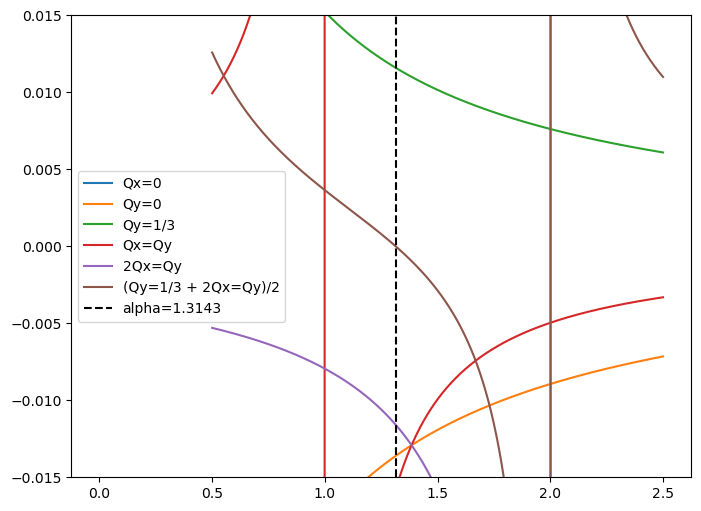

In [3]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
Qp = 20.13/2
alpha = np.linspace(0.5, 2.5, 1000)
ax.plot(np.zeros(1000), np.ones(1000) * -0.13/Qp, label=f'Qx=0')
ax.plot(alpha, -0.18/alpha/Qp, label='Qy=0')
ax.plot(alpha, 0.1533/alpha/Qp, label='Qy=1/3')
ax.plot(alpha, 0.05/(1-alpha)/Qp, label='Qx=Qy')
ax.plot(alpha, -0.08/(2-alpha)/Qp, label='2Qx=Qy')
ax.plot(alpha, (0.1533/alpha/Qp -0.08/(2-alpha)/Qp)/2, label='(Qy=1/3 + 2Qx=Qy)/2')
ax.set_ylim(-1.5e-2,1.5e-2)
ax.vlines(1.3143, -1.5e-2, 1.5e-2, ls='--', color='k', label='alpha=1.3143')
ax.legend()

In [15]:
%matplotlib tk

(-0.015, 0.015)

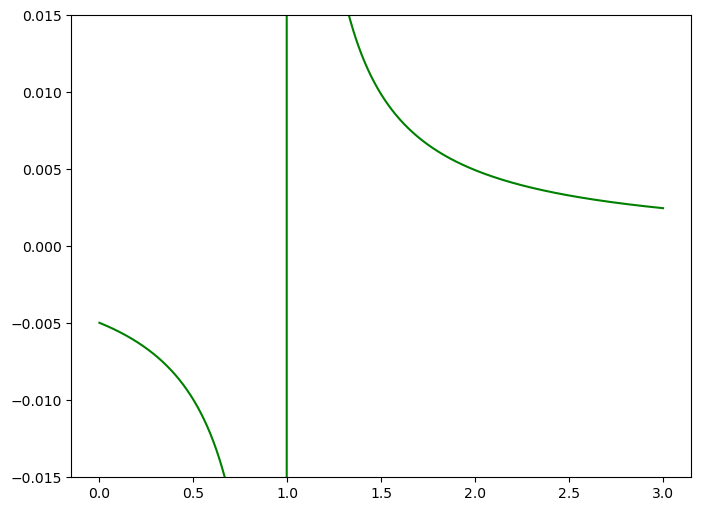

In [4]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
Qx = 20.13
Qy = 20.18
xi = 0.5
alpha = np.linspace(1e-16, 3.0, 2000)
ax.plot(alpha, np.ones(len(alpha))*1/xi, color='indigo', label=r'Q_x = 0')
# ax.plot(alpha, 1/xi/alpha, color='orangered', label=r'Q_y = 0')
ax.plot(alpha, (Qy-Qx)/(xi*(alpha*Qy-Qx)), color='green', label=r'Q_x=Q_y')
ax.plot(alpha, (1-Qx-2*Qy)/(xi*(alpha*Qy+Qx)), color='orange', label=r'Q_x+2Q_y=1')
ax.set_ylim(-1.5e-2,1.5e-2)